In [4]:
import ocha_stratus as stratus
from dotenv import load_dotenv
import pandas as pd
load_dotenv()

True

In [3]:
engine = stratus.get_engine("prod")

In [14]:
with engine.connect() as conn:
    df_flood_exp = pd.read_sql(
        "select * from app.floodscan_exposure where adm_level='2' and iso3='NGA'",
        con=conn
    )

In [15]:
df_flood_exp

,iso3,adm_level,valid_date,pcode,sum
0,NGA,2,2025-01-01,NG001001,0.0
1,NGA,2,2025-01-01,NG001002,0.0
2,NGA,2,2025-01-01,NG001003,0.0
3,NGA,2,2025-01-01,NG001004,0.0
4,NGA,2,2025-01-01,NG001005,0.0
...,...,...,...,...,...
8000059,NGA,2,2026-05-02,NG037010,0.0
8000060,NGA,2,2026-05-02,NG037011,0.0
8000061,NGA,2,2026-05-02,NG037012,0.0
8000062,NGA,2,2026-05-02,NG037013,0.0


In [26]:
df_flood_exp["valid_date"] = pd.to_datetime(df_flood_exp["valid_date"])
df_flood_exp["year"] = df_flood_exp["valid_date"].dt.year

df_avg_annual_max = (
    df_flood_exp.groupby(["pcode", "year"])["sum"]
    .max()
    .groupby("pcode")
    .std()
    .reset_index()
    .rename(columns={"sum": "avg_annual_max"})
)
df_avg_annual_max

,pcode,avg_annual_max
0,NG001001,3464.380819
1,NG001002,8815.442151
2,NG001003,1589.452524
3,NG001004,826.552245
4,NG001005,147.658081
...,...,...
769,NG037010,5631.458929
770,NG037011,7427.478657
771,NG037012,10929.166108
772,NG037013,13256.566734


✓ OCHA visual style applied


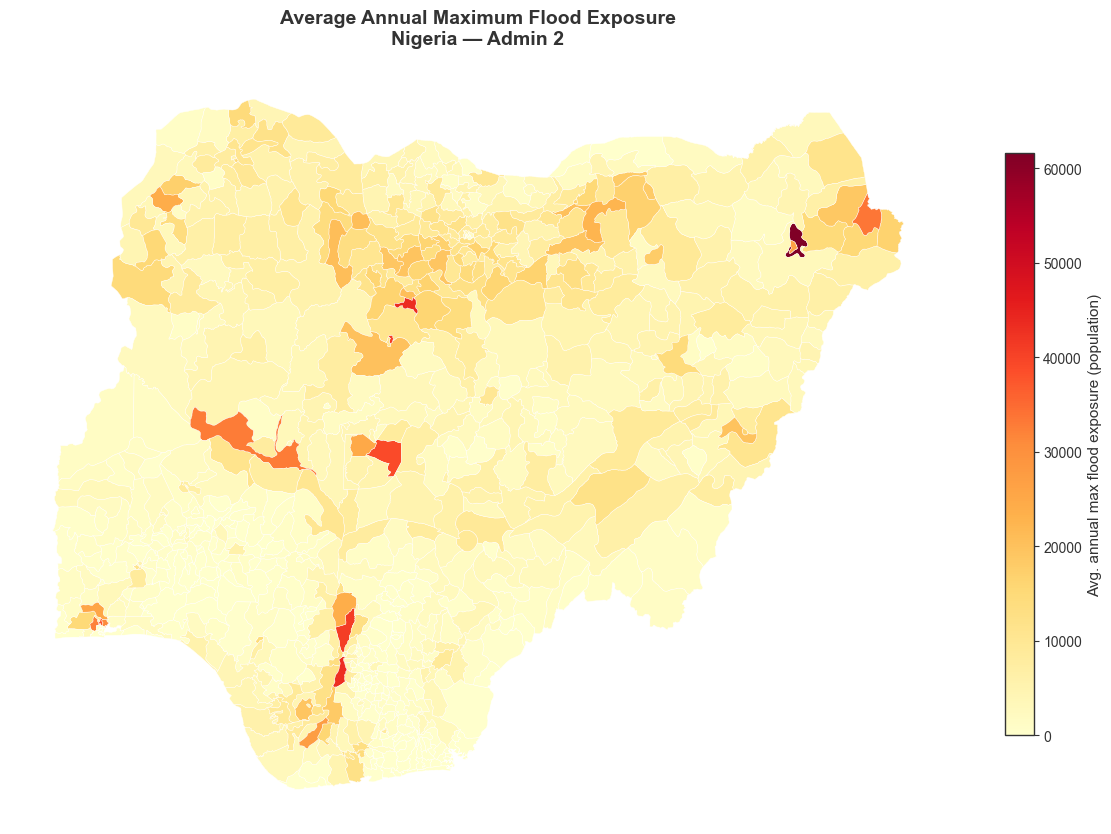

In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
sys.path.append("/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/exploration/2026/quarto")
from ocha_style import setup_ocha_style
setup_ocha_style()

gdf_adm2 = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf = gdf_adm2.merge(df_avg_annual_max, left_on="ADM2_PCODE", right_on="pcode", how="left")

fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(
    column="avg_annual_max",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Avg. annual max flood exposure (population)", "shrink": 0.6},
    missing_kwds={"color": "#f0f0f0"},
    edgecolor="white",
    linewidth=0.3,
)
ax.set_title("Average Annual Maximum Flood Exposure\nNigeria — Admin 2", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("figures/avg_std_max_flood_exposure.png", dpi=300)

In [21]:
gdf.sort_values("avg_annual_max", ascending=False).head(10)[["ADM2_PCODE", "ADM2_EN", "avg_annual_max"]]

,ADM2_PCODE,ADM2_EN,avg_annual_max
52,NG004003,Anambra West,67494.551724
524,NG008025,Ngala,63028.586207
507,NG027017,Mokwa,55620.862069
387,NG008013,Jere,52908.344828
563,NG004016,Ogbaru,50570.448276
745,NG010024,Warri South,48518.448276
763,NG002021,Yola South,41970.827586
405,NG008015,Kala/Balge,37932.551724
279,NG023006,Ibaji,37085.137931
446,NG008017,Kukawa,36213.517241
